# Model Evaluation Analysis — Cross-Model (4k common subset)

Fair **1:1** comparison of four models on the *same* 4,000 claim ids (built by `scripts/build_subsample_results_db.py` → `results/results_am_subsample.db`).

| Model | Coverage |
|---|---|
| Bielik-11B | full benchmark, restricted here to 4k |
| llama3.1:8b | full benchmark, restricted here to 4k |
| qwen2.5:7b | 4k subset |
| PLLuM-8B | 4k subset |

Agents ga1–ga7 (zero-shot → adversarial debate+RAG).

In [ ]:
import re
import sqlite3
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110

conn = sqlite3.connect("../results/results_am_subsample.db")

# 4-model palette (extends data_discovery's 2-colour scheme)
PALETTE = {
    "Bielik-11B":  "#E07B54",
    "llama3.1:8b": "#4C72B0",
    "qwen2.5:7b":  "#55A868",
    "PLLuM-8B":    "#C44E52",
}
MODEL_ORDER = ["Bielik-11B", "llama3.1:8b", "qwen2.5:7b", "PLLuM-8B"]

def _short_model(m):
    m = str(m)
    if "Bielik" in m: return "Bielik-11B"
    if "PLLuM"  in m: return "PLLuM-8B"
    if "qwen"   in m: return "qwen2.5:7b"
    return "llama3.1:8b"

# Active roster (renumbered): old web-ReAct ga2 discontinued -> uam_ga_web_tool_arch;
# old ga3-ga7 shifted down to ga2-ga6.
AGENT_META = {
    "uam_ga1": ("ga1\nZero-shot",     1),
    "uam_ga2": ("ga2\nBM25",          1),
    "uam_ga3": ("ga3\nRAG+Decomp",    2),
    "uam_ga4": ("ga4\nBM25+Decomp",   2),
    "uam_ga5": ("ga5\nFewShot+RAG",   3),
    "uam_ga6": ("ga6\nDebate+RAG",    3),
}
AGENT_ORDER = list(AGENT_META.keys())
LABEL_ORDER = [v[0] for v in AGENT_META.values()]

In [ ]:
# Master dataframe: results joined to benchmark claims (topic / year / type)
df = pd.read_sql_query("""
    SELECT r.agent_name, r.model_name, r.claim_id, r.is_correct,
           r.model_label, r.original_label,
           r.time_thought, r.total_tokens, r.prompt_tokens, r.completion_tokens,
           r.created_at, c.topic, c.claim_date, c.exam_type
    FROM agent_results r
    LEFT JOIN claims c ON c.id = r.claim_id
    WHERE r.agent_name NOT LIKE 'uam_ga_web_tool_arch%'
""", conn)

df["model"]      = df["model_name"].apply(_short_model)
df["base_agent"] = df["agent_name"].str.extract(r"^(uam_ga\d+)")
df["label"]      = df["base_agent"].map(lambda a: AGENT_META.get(a, (a, 0))[0])
df["tier"]       = df["base_agent"].map(lambda a: AGENT_META.get(a, (a, 0))[1])
df["created_at"] = pd.to_datetime(df["created_at"], utc=True, errors="coerce")
df["year"]       = pd.to_numeric(df["claim_date"], errors="coerce")

VALID = {"0", "1", "2", "3"}
# Predicted labels that are not 0-3 (ERROR_MAX_STEPS, floats, ...) -> INVALID.
# Accuracy uses the stored is_correct; INVALID rows count as incorrect.
df["pred_bucket"] = df["model_label"].where(df["model_label"].isin(VALID), "INVALID")

print(f"{len(df):,} rows | {df['base_agent'].nunique()} agents | "
      f"{df['model'].nunique()} models | {df['claim_id'].nunique():,} claims")
print("INVALID predictions:",
      (df['pred_bucket'] == 'INVALID').sum(),
      f"({(df['pred_bucket']=='INVALID').mean()*100:.2f}%)")
df.head(3)

## Pivot tables — accuracy & cost by agent × model

In [ ]:
def _order(p):
    return p.reindex(index=AGENT_ORDER, columns=MODEL_ORDER)

# 1) Accuracy (%) per agent x model
acc_pivot = (_order(df.pivot_table("is_correct", "base_agent", "model", "mean")) * 100).round(1)
acc_pivot

In [ ]:
# 2) Total tokens consumed per agent x model
tok_pivot = _order(df.pivot_table("total_tokens", "base_agent", "model", "sum")).astype("Int64")
tok_pivot

In [ ]:
# 3) Avg prompt:completion token ratio per agent x model
avg_p = df.pivot_table("prompt_tokens", "base_agent", "model", "mean")
avg_c = df.pivot_table("completion_tokens", "base_agent", "model", "mean")
ratio_pivot = _order(avg_p / avg_c).round(2)
ratio_pivot

In [ ]:
# 4) Avg evaluation time (s) per claim, per agent x model
time_pivot = _order(df.pivot_table("time_thought", "base_agent", "model", "mean")).round(2)
time_pivot

In [ ]:
# 5) Master summary table (all metrics, per agent x model)
summary = pd.read_sql_query("""
    SELECT agent_name, model_name,
           COUNT(*)                                                    AS n,
           ROUND(100.0*SUM(is_correct)/COUNT(*), 2)                    AS accuracy_pct,
           SUM(total_tokens)                                           AS total_tokens,
           ROUND(AVG(prompt_tokens), 1)                               AS avg_prompt_tokens,
           ROUND(AVG(completion_tokens), 1)                           AS avg_completion_tokens,
           ROUND(AVG(prompt_tokens)/NULLIF(AVG(completion_tokens),0), 2) AS prompt_completion_ratio,
           ROUND(AVG(time_thought), 3)                                AS avg_time_s,
           ROUND(AVG(time_thought)/NULLIF(AVG(total_tokens),0), 6)    AS avg_time_per_token,
           ROUND(SUM(total_tokens)/NULLIF(SUM(is_correct),0), 1)      AS tokens_per_correct
    FROM agent_results
    GROUP BY agent_name, model_name
    ORDER BY agent_name, model_name
""", conn)
summary["model"] = summary["model_name"].apply(_short_model)
summary

## Visualizations

In [ ]:
# Per-(agent, model) aggregate reused by several plots
agent_summary = (
    df.groupby(["base_agent", "model", "label", "tier"], observed=True)
      .agg(accuracy_pct=("is_correct", lambda s: s.mean() * 100),
           median_time =("time_thought", "median"),
           avg_time    =("time_thought", "mean"),
           avg_tokens  =("total_tokens", "mean"))
      .reset_index()
)
agent_summary["label"] = pd.Categorical(agent_summary["label"], LABEL_ORDER, ordered=True)
agent_summary = agent_summary.sort_values(["label", "model"])

In [ ]:
# Graph 1 — Accuracy by agent (grouped bars) + cumulative mean across agents
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Accuracy by Agent & Model  (4k common subset)", fontsize=13, fontweight="bold")

sns.barplot(data=agent_summary, x="label", y="accuracy_pct", hue="model",
            hue_order=MODEL_ORDER, palette=PALETTE, order=LABEL_ORDER, ax=axes[0])
for c in axes[0].containers:
    axes[0].bar_label(c, fmt="%.0f", padding=2, fontsize=7)
ymax = agent_summary["accuracy_pct"].max() * 1.18
axes[0].set_ylim(0, ymax)
for x in (2.5, 4.5):
    axes[0].axvline(x, color="grey", lw=0.8, ls=":")
for x, lbl in ((1.0, "Tier 1"), (3.5, "Tier 2"), (5.0, "Tier 3")):
    axes[0].text(x, ymax * 0.96, lbl, ha="center", fontsize=8, color="grey")
axes[0].set_title("Accuracy by Agent", fontsize=11)
axes[0].set_xlabel("Agent  ->  increasing complexity"); axes[0].set_ylabel("Accuracy (%)")
axes[0].tick_params(axis="x", labelsize=9); axes[0].legend(title="Model", fontsize=8)

# cumulative (running) mean accuracy as agents are added ga1..ga7
for m in MODEL_ORDER:
    cum = acc_pivot[m].expanding().mean()
    axes[1].plot(range(len(acc_pivot)), cum, marker="o", color=PALETTE[m], label=m)
axes[1].set_xticks(range(len(acc_pivot)))
axes[1].set_xticklabels([AGENT_META[a][0] for a in acc_pivot.index], fontsize=8)
axes[1].set_title("Cumulative Mean Accuracy Across Agents\n(running mean as complexity grows)",
                  fontsize=11)
axes[1].set_xlabel("Agents included (cumulative)"); axes[1].set_ylabel("Cumulative mean accuracy (%)")
axes[1].legend(title="Model", fontsize=8)
plt.tight_layout(); plt.show()

In [ ]:
# Graph 2 — Rolling accuracy over claim IDs (ga1, all 4 models)
WINDOW = 100
AGENT_ROLL = "uam_ga1"
sub = df[df.base_agent == AGENT_ROLL]
fig, ax = plt.subplots(figsize=(14, 5))
for m in MODEL_ORDER:
    g = sub[sub.model == m].sort_values("claim_id").reset_index(drop=True)
    roll = g["is_correct"].rolling(WINDOW, center=True, min_periods=30).mean() * 100
    overall = g["is_correct"].mean() * 100
    ax.plot(g["claim_id"], roll, color=PALETTE[m], lw=1.4, label=f"{m} ({overall:.1f}%)")
    ax.axhline(overall, color=PALETTE[m], ls="--", lw=0.7, alpha=0.5)
ax.set_title(f"{AGENT_ROLL} — Rolling Accuracy vs Claim ID  (window={WINDOW})",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Claim ID"); ax.set_ylabel("Rolling accuracy (%)")
ax.legend(title="Model", fontsize=9)
plt.tight_layout(); plt.show()

C:\Users\piotr\AppData\Local\Temp\ipykernel_2380\1432153574.py:16: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\piotr\claims_processing\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


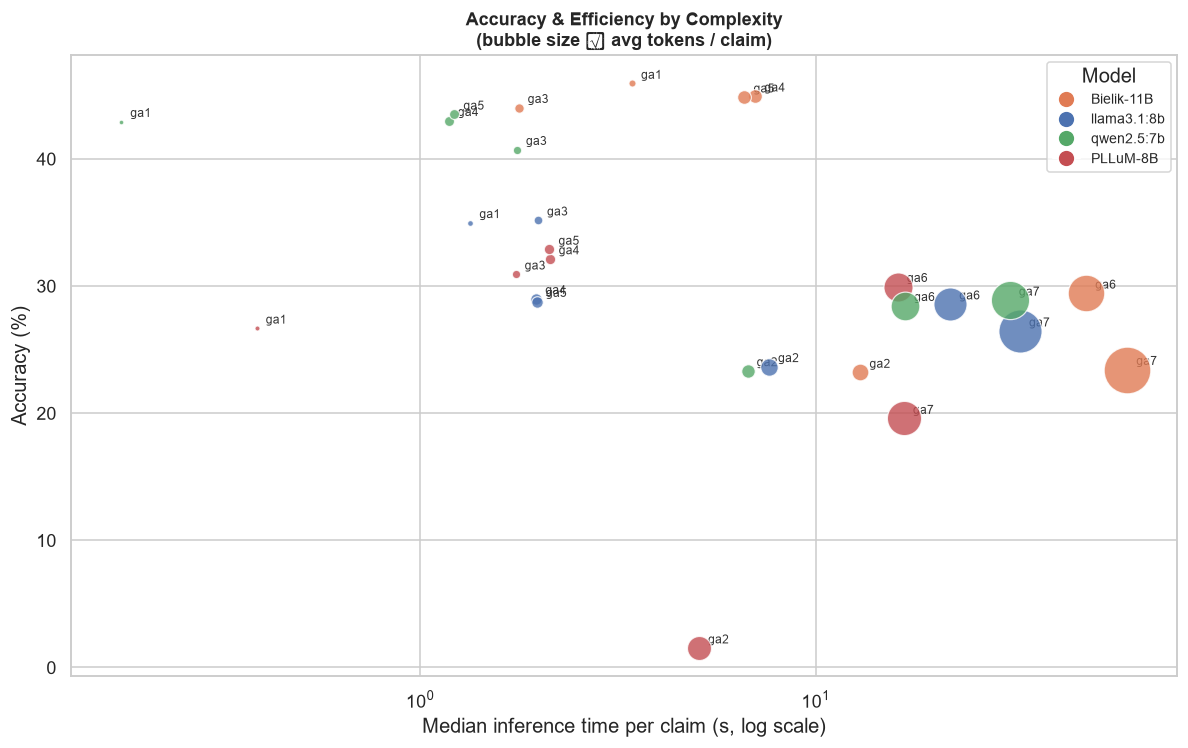

In [ ]:
# Graph 3 — Accuracy & efficiency by complexity (bubble size ∝ avg tokens)
fig, ax = plt.subplots(figsize=(11, 7))
for _, r in agent_summary.iterrows():
    ax.scatter(r["median_time"], r["accuracy_pct"], color=PALETTE[r["model"]],
               s=r["avg_tokens"] / 30, alpha=0.8, edgecolors="white", lw=0.8, zorder=5)
    ax.annotate(r["label"].split("\n")[0], (r["median_time"], r["accuracy_pct"]),
                xytext=(6, 3), textcoords="offset points", fontsize=8, color="#333")
handles = [Line2D([0], [0], marker="o", color="w", markerfacecolor=PALETTE[m],
                  markersize=11, label=m) for m in MODEL_ORDER]
ax.legend(handles=handles, title="Model", fontsize=9)
ax.set_xscale("log")
ax.set_xlabel("Median inference time per claim (s, log scale)")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy & Efficiency by Complexity\n(bubble size ∝ avg tokens / claim)",
             fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

In [ ]:
# Graph 4 — Per-claim distributions: inference time & tokens
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Per-claim Distributions — Inference Time & Token Usage",
             fontsize=13, fontweight="bold")
bp = dict(order=LABEL_ORDER, hue_order=MODEL_ORDER, palette=PALETTE, showfliers=False)

sns.boxplot(data=df, x="label", y="time_thought", hue="model", ax=axes[0], **bp)
axes[0].set_title("Inference Time (outliers hidden)")
axes[0].set_ylabel("Time per claim (s)"); axes[0].set_xlabel("Agent  ->  complexity")
axes[0].tick_params(axis="x", labelsize=9); axes[0].legend(title="Model", fontsize=8)

sns.boxplot(data=df, x="label", y="total_tokens", hue="model", ax=axes[1], **bp)
axes[1].set_yscale("log")
axes[1].set_title("Token Usage (log scale, outliers hidden)")
axes[1].set_ylabel("Tokens per claim (log)"); axes[1].set_xlabel("Agent  ->  complexity")
axes[1].tick_params(axis="x", labelsize=9); axes[1].legend(title="Model", fontsize=8)
plt.tight_layout(); plt.show()

In [ ]:
# Graph 5 — Predicted vs actual labels + confusion matrices (graph-7 style, 4 models)
from sklearn.metrics import confusion_matrix

AGENT_CM = "uam_ga1"
LABELS_CM = ["0", "1", "2", "3", "INVALID"]
sub = df[df.base_agent == AGENT_CM]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle(f"{AGENT_CM} — Predicted vs Actual Labels  (4k subset)",
             fontsize=13, fontweight="bold")
for j, m in enumerate(MODEL_ORDER):
    g = sub[sub.model == m]
    gv = g[g.model_label.isin(VALID)]
    ldf = pd.concat([
        gv["original_label"].rename("label").to_frame().assign(source="Ground Truth"),
        gv["model_label"].rename("label").to_frame().assign(source="Predicted"),
    ], ignore_index=True)
    sns.countplot(data=ldf, x="label", hue="source", order=["0", "1", "2", "3"],
                  palette={"Ground Truth": "#aaaaaa", "Predicted": PALETTE[m]}, ax=axes[0, j])
    axes[0, j].set_title(m, fontsize=10); axes[0, j].set_xlabel("Label")
    axes[0, j].legend(fontsize=7, title="")

    cm = confusion_matrix(g["original_label"], g["pred_bucket"], labels=LABELS_CM)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=LABELS_CM, yticklabels=LABELS_CM, ax=axes[1, j])
    axes[1, j].set_title(f"{m} — confusion", fontsize=10)
    axes[1, j].set_xlabel("Predicted"); axes[1, j].set_ylabel("Actual")
plt.tight_layout(); plt.show()

In [ ]:
# Graph 6 — Prompt vs completion token distributions (ga1, 4 models)
AGENT_TOK = "uam_ga1"
sub = df[(df.base_agent == AGENT_TOK) & (df.model_label.isin(VALID))]
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f"{AGENT_TOK} — Prompt vs Completion Tokens", fontsize=13, fontweight="bold")
for col, (tc, title) in enumerate([("prompt_tokens", "Prompt (input) tokens"),
                                   ("completion_tokens", "Completion (output) tokens")]):
    ax = axes[col]
    hi = sub[tc].quantile(0.99)
    for m in MODEL_ORDER:
        g = sub[sub.model == m]; med = g[tc].median()
        sns.histplot(g[g[tc] <= hi], x=tc, bins=80, kde=True, color=PALETTE[m],
                     alpha=0.4, label=f"{m} (med {med:.0f})", ax=ax)
        ax.axvline(med, color=PALETTE[m], ls="--", lw=1)
    ax.set_title(title); ax.set_xlabel("Tokens"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Benchmark dimensions — topic categories & exam year
154 raw topics grouped into families: exam-code prefixes (R., M., …) vs named subjects. Accuracy pooled over agents unless noted.

In [ ]:
def topic_family(t):
    t = str(t)
    m = re.match(r"^([A-Za-z]+)\.\d", t)   # exam codes like R.13, M.39
    return (m.group(1).upper() + " (exam code)") if m else t

df["topic_family"] = df["topic"].apply(topic_family)

fam_acc = (df.pivot_table("is_correct", "topic_family", "model", "mean") * 100)
fam_acc = fam_acc.reindex(columns=MODEL_ORDER).round(1)
fam_n = df[df.model == MODEL_ORDER[0]].groupby("topic_family")["claim_id"].nunique()
fam_acc = fam_acc.assign(n_claims=fam_n).sort_values("n_claims", ascending=False)
fam_acc

model,Bielik-11B,llama3.1:8b,qwen2.5:7b,PLLuM-8B,n_claims
topic_family,,,,,
M (exam code),34.7,28.3,34.1,23.5,1393
R (exam code),37.9,30.6,36.2,25.1,1176
MG (exam code),35.9,28.3,34.5,23.1,508
RL (exam code),35.9,27.5,33.7,25.1,399
S (exam code),37.1,31.0,41.0,29.6,202
ST (exam code),48.4,40.1,50.5,31.2,143
Matematyka,28.6,27.7,30.7,19.9,82
Fizyka,36.8,27.1,43.6,35.4,40
M.YY,35.4,36.1,38.1,24.5,21


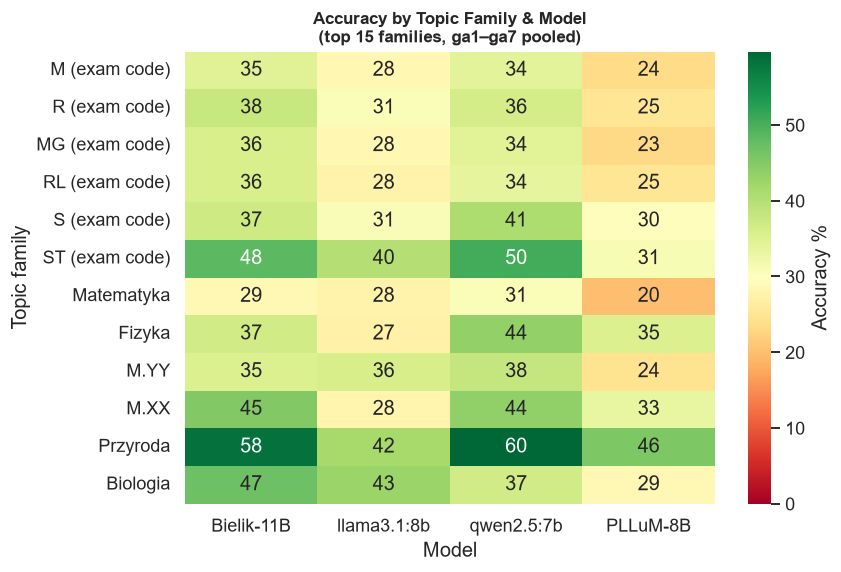

In [ ]:
# Accuracy by topic family & model (top families by #claims)
top_fams = fam_acc.head(15).index
fig, ax = plt.subplots(figsize=(8, max(4, len(top_fams) * 0.45)))
sns.heatmap(fam_acc.loc[top_fams, MODEL_ORDER], annot=True, fmt=".0f", cmap="RdYlGn",
            vmin=0, cbar_kws={"label": "Accuracy %"}, ax=ax)
ax.set_title("Accuracy by Topic Family & Model\n(top 15 families, ga1–ga7 pooled)",
             fontsize=11, fontweight="bold")
ax.set_ylabel("Topic family"); ax.set_xlabel("Model")
plt.tight_layout(); plt.show()

In [ ]:
# Top-N hardest / easiest individual topics (min claim count to avoid noise)
MIN_CLAIMS = 15
by_topic = (df.groupby("topic")
              .agg(n_claims=("claim_id", "nunique"),
                   accuracy=("is_correct", lambda s: s.mean() * 100))
              .query("n_claims >= @MIN_CLAIMS")
              .sort_values("accuracy"))
print(f"Topics with >= {MIN_CLAIMS} claims: {len(by_topic)}")
print("\nHardest 10 topics (pooled over models & agents):")
display(by_topic.head(10).round(1))
print("Easiest 10 topics:")
display(by_topic.tail(10).round(1))

Topics with >= 15 claims: 90

Hardest 10 topics (pooled over models & agents):


,n_claims,accuracy
topic,,
S.01,25,22.4
MG.03,22,22.6
MG.42,18,22.6
RL.24,21,24.7
MG.14,33,24.9
RL.14,38,25.1
M.08,44,25.5
MG.38,18,26.0
RL.04,48,26.0


Easiest 10 topics:


,n_claims,accuracy
topic,,
R.07,56,37.6
S.03,38,38.0
S.04,20,38.6
S.02,27,40.2
R.06,82,41.6
ST.05,37,42.3
R.10,50,43.1
ST.04,54,43.1
ST.02,37,43.2


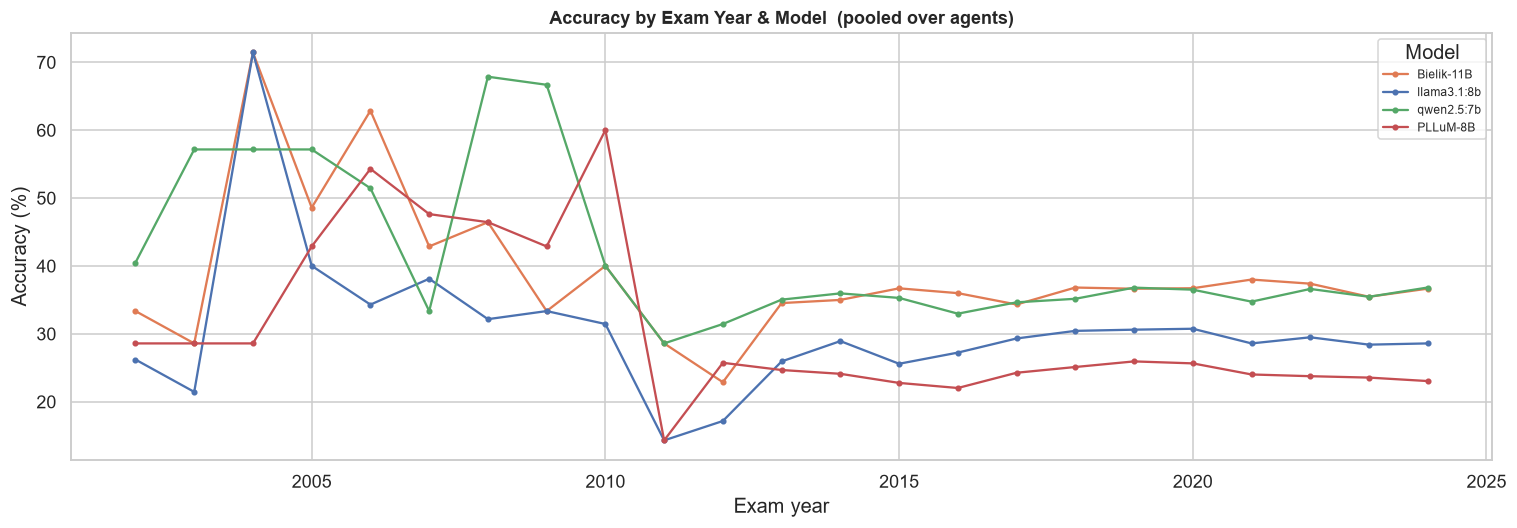

In [ ]:
# Accuracy by exam year & model
yr = (df.dropna(subset=["year"]).pivot_table("is_correct", "year", "model", "mean") * 100)
yr = yr.reindex(columns=MODEL_ORDER)
fig, ax = plt.subplots(figsize=(14, 5))
for m in MODEL_ORDER:
    ax.plot(yr.index, yr[m], marker="o", ms=3, color=PALETTE[m], label=m)
ax.set_title("Accuracy by Exam Year & Model  (pooled over agents)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Exam year"); ax.set_ylabel("Accuracy (%)"); ax.legend(title="Model", fontsize=8)
plt.tight_layout(); plt.show()